# Notebook 3 — Renewable Availability: Solar & Wind

Renewables are "free" to run but not always available. This notebook explores the two stochastic availability models:

1. **Solar** — deterministic Gaussian envelope (month x hour) + Markov cloud chain
2. **Wind** — AR(1) process in Gaussian space → Weibull speed → turbine power curve

By the end you will understand:
- Why solar output is predictable in shape but noisy in magnitude
- Why wind output clusters (storms last hours, not minutes)
- The seasonal anti-correlation that makes solar + wind complementary

**Runtime**: < 10 seconds

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from energy_sim.models import TimeGrid
from energy_sim.generators import SolarAvailability, WindAvailability
from energy_sim.config import (
    QUARTERS_PER_DAY, MONTHLY_SOLAR_FACTORS, HOURLY_SOLAR_ENVELOPE,
    CLOUD_TRANSITION, MONTHLY_WIND_LAMBDA, WIND_WEIBULL_K,
    WIND_CUT_IN, WIND_RATED, WIND_CUT_OUT,
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

tg = TimeGrid()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

## 1. Solar Availability

### 1.1 The deterministic envelope

Solar irradiance follows a Gaussian bell curve centered around 13:00 (Italian solar noon), shaped by season. Night hours are hard-zeroed.

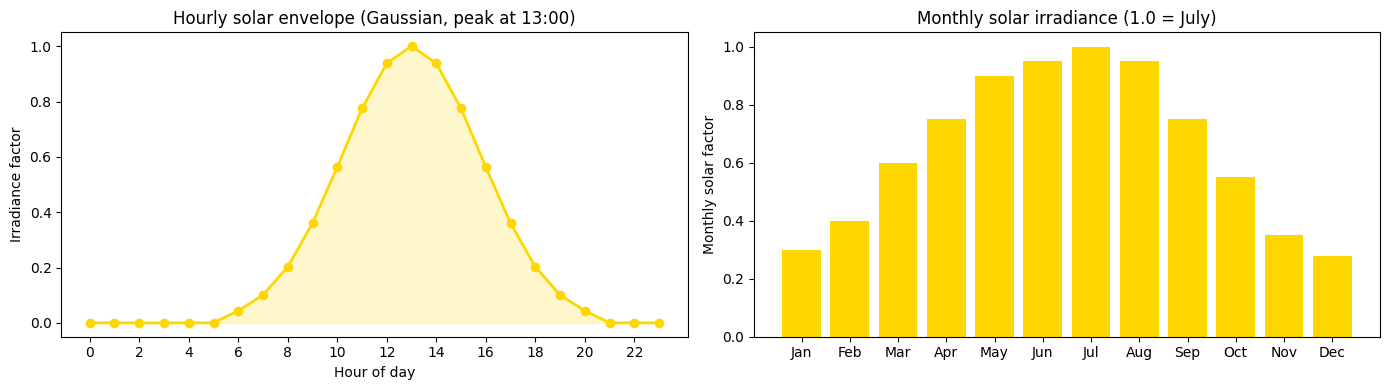

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hourly envelope
hours = list(range(24))
envelope = [HOURLY_SOLAR_ENVELOPE[h] for h in hours]
axes[0].plot(hours, envelope, 'o-', color='gold', lw=2)
axes[0].fill_between(hours, envelope, alpha=0.2, color='gold')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Irradiance factor')
axes[0].set_title('Hourly solar envelope (Gaussian, peak at 13:00)')
axes[0].set_xticks(range(0, 24, 2))

# Monthly factors
m_factors = [MONTHLY_SOLAR_FACTORS[m] for m in range(1, 13)]
axes[1].bar(month_names, m_factors, color='gold')
axes[1].set_ylabel('Monthly solar factor')
axes[1].set_title('Monthly solar irradiance (1.0 = July)')

plt.tight_layout()
plt.show()

### 1.2 The cloud Markov chain

On top of the deterministic envelope, a **two-state daily Markov chain** models cloud cover:
- **Sunny** → cloudy with probability $P(S \to C)$
- **Cloudy** → sunny with probability $P(C \to S)$

Transition probabilities vary by month (cloudier in winter, clearer in summer):

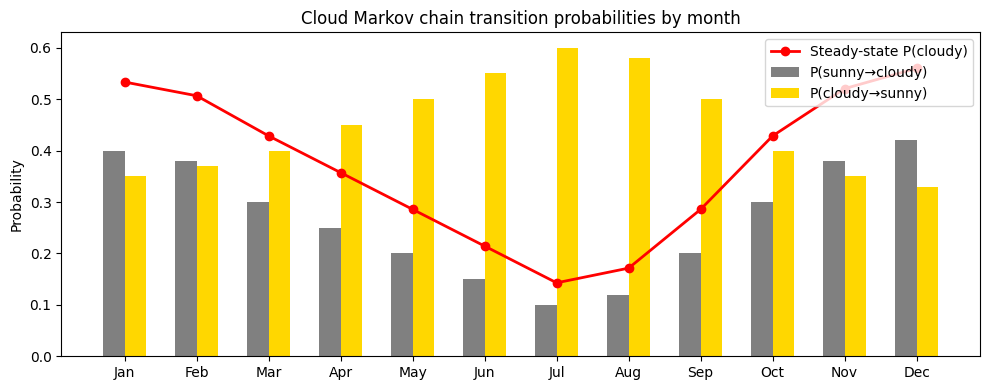

Steady-state cloudy probability:
  Jan: 53% cloudy
  Feb: 51% cloudy
  Mar: 43% cloudy
  Apr: 36% cloudy
  May: 29% cloudy
  Jun: 21% cloudy
  Jul: 14% cloudy
  Aug: 17% cloudy
  Sep: 29% cloudy
  Oct: 43% cloudy
  Nov: 52% cloudy
  Dec: 56% cloudy


In [3]:
p_s2c = [CLOUD_TRANSITION[m][0] for m in range(1, 13)]
p_c2s = [CLOUD_TRANSITION[m][1] for m in range(1, 13)]
steady_cloudy = [s / (s + c) for s, c in zip(p_s2c, p_c2s)]  # steady-state P(cloudy)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(12)
ax.bar(x - 0.15, p_s2c, 0.3, label='P(sunny→cloudy)', color='gray')
ax.bar(x + 0.15, p_c2s, 0.3, label='P(cloudy→sunny)', color='gold')
ax.plot(x, steady_cloudy, 'ro-', label='Steady-state P(cloudy)', lw=2)
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_ylabel('Probability')
ax.set_title('Cloud Markov chain transition probabilities by month')
ax.legend()
plt.tight_layout()
plt.show()

print("Steady-state cloudy probability:")
for m, p in enumerate(steady_cloudy):
    print(f"  {month_names[m]:>3s}: {p:.0%} cloudy")

### 1.3 Full solar profile

Envelope × cloud attenuation:

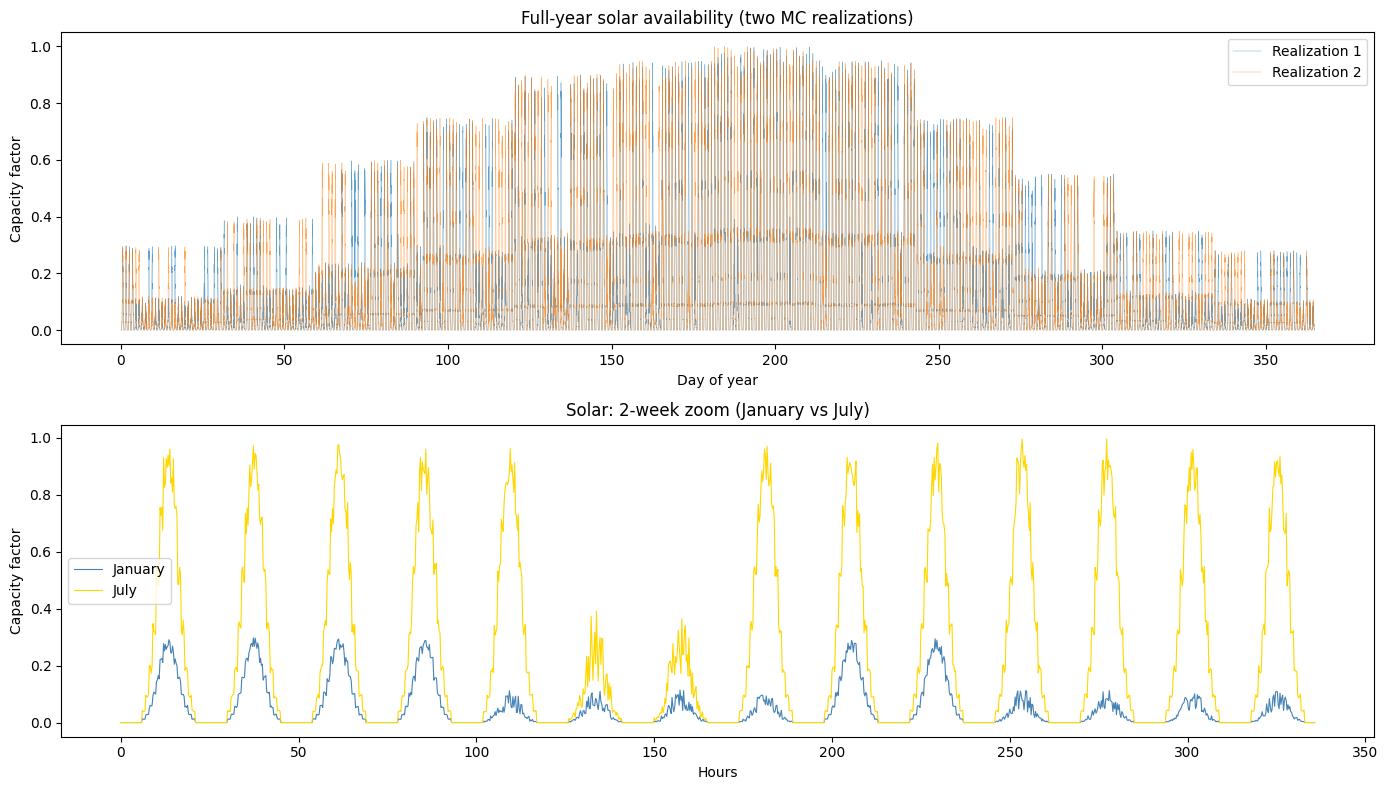

Monthly average capacity factors:
  Jan: 0.048
  Feb: 0.061
  Mar: 0.103
  Apr: 0.154
  May: 0.182
  Jun: 0.207
  Jul: 0.250
  Aug: 0.238
  Sep: 0.163
  Oct: 0.104
  Nov: 0.059
  Dec: 0.051


In [4]:
solar = SolarAvailability()
days_axis = np.arange(tg.n) / QUARTERS_PER_DAY

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Two different realizations
for i, seed in enumerate([42, 99]):
    profile = solar.generate_profile(tg, np.random.default_rng(seed))
    axes[0].plot(days_axis, profile, lw=0.3, alpha=0.7, label=f'Realization {i+1}')

axes[0].set_xlabel('Day of year')
axes[0].set_ylabel('Capacity factor')
axes[0].set_title('Full-year solar availability (two MC realizations)')
axes[0].legend()

# Zoom: 2 weeks in summer and winter
profile = solar.generate_profile(tg, np.random.default_rng(42))
jan_slice = slice(0, 14 * QUARTERS_PER_DAY)
jul_slice = slice(182 * QUARTERS_PER_DAY, 196 * QUARTERS_PER_DAY)
hours_2w = np.arange(14 * QUARTERS_PER_DAY) / 4

axes[1].plot(hours_2w, profile[jan_slice], lw=0.8, label='January', color='steelblue')
axes[1].plot(hours_2w, profile[jul_slice], lw=0.8, label='July', color='gold')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Capacity factor')
axes[1].set_title('Solar: 2-week zoom (January vs July)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Monthly capacity factors
print("Monthly average capacity factors:")
for m in range(1, 13):
    mask = tg.month == m
    print(f"  {month_names[m-1]:>3s}: {profile[mask].mean():.3f}")

## 2. Wind Availability

### 2.1 The Weibull distribution and power curve

Wind speeds follow a **Weibull distribution** (shape $k$, scale $\lambda$). The turbine's power curve converts speed to electrical output.

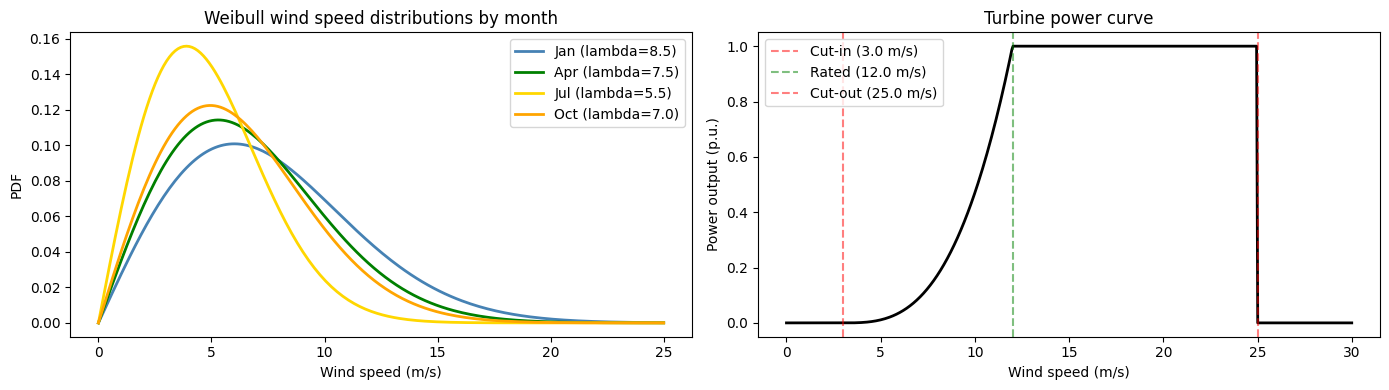

In [5]:
from scipy.stats import weibull_min

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Weibull PDFs for different months
v = np.linspace(0, 25, 200)
for m, color, name in [(1, 'steelblue', 'Jan'), (4, 'green', 'Apr'),
                        (7, 'gold', 'Jul'), (10, 'orange', 'Oct')]:
    lam = MONTHLY_WIND_LAMBDA[m]
    pdf = weibull_min.pdf(v, WIND_WEIBULL_K, scale=lam)
    axes[0].plot(v, pdf, lw=2, color=color, label=f'{name} (lambda={lam:.1f})')

axes[0].set_xlabel('Wind speed (m/s)')
axes[0].set_ylabel('PDF')
axes[0].set_title('Weibull wind speed distributions by month')
axes[0].legend()

# Turbine power curve
wind_model = WindAvailability()
v_curve = np.linspace(0, 30, 500)
power_curve = wind_model._power_curve(v_curve)

axes[1].plot(v_curve, power_curve, 'k-', lw=2)
axes[1].axvline(WIND_CUT_IN, color='red', ls='--', alpha=0.5, label=f'Cut-in ({WIND_CUT_IN} m/s)')
axes[1].axvline(WIND_RATED, color='green', ls='--', alpha=0.5, label=f'Rated ({WIND_RATED} m/s)')
axes[1].axvline(WIND_CUT_OUT, color='red', ls='--', alpha=0.5, label=f'Cut-out ({WIND_CUT_OUT} m/s)')
axes[1].set_xlabel('Wind speed (m/s)')
axes[1].set_ylabel('Power output (p.u.)')
axes[1].set_title('Turbine power curve')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.2 AR(1) autocorrelation

Wind is NOT just random draws from Weibull. Real wind is **autocorrelated** — a windy hour predicts the next hour will be windy too (weather fronts last days, not minutes).

The model uses an AR(1) process in Gaussian space:

$$z_t = \phi \cdot z_{t-1} + \sqrt{1-\phi^2} \cdot \epsilon_t$$

with $\phi = 0.995$ (very high persistence), then transforms to Weibull via the probability integral transform.

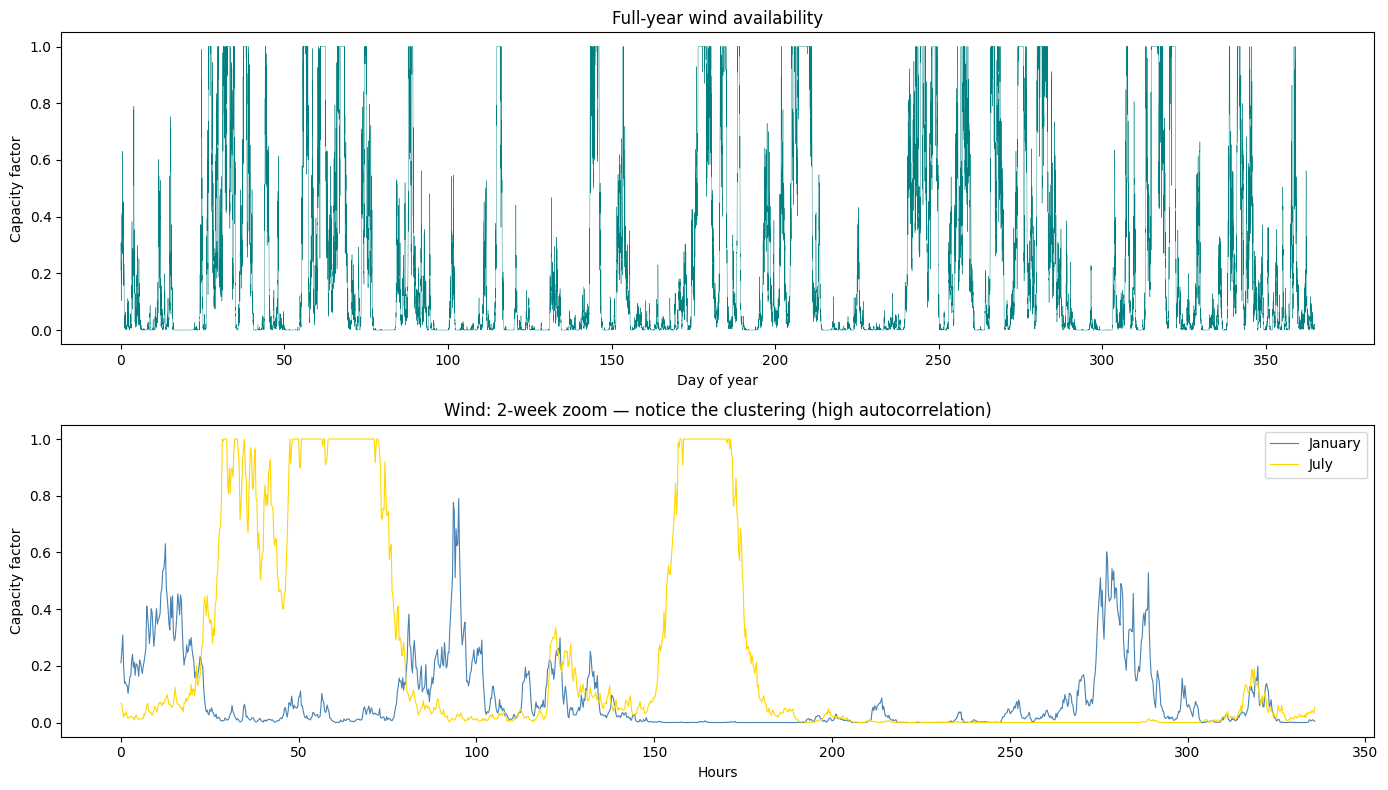

Monthly average wind capacity factors:
  Jan: 0.137  (lambda=8.5 m/s)
  Feb: 0.307  (lambda=8.2 m/s)
  Mar: 0.316  (lambda=7.8 m/s)
  Apr: 0.096  (lambda=7.5 m/s)
  May: 0.114  (lambda=6.8 m/s)
  Jun: 0.225  (lambda=6.0 m/s)
  Jul: 0.368  (lambda=5.5 m/s)
  Aug: 0.073  (lambda=5.8 m/s)
  Sep: 0.378  (lambda=6.5 m/s)
  Oct: 0.261  (lambda=7.0 m/s)
  Nov: 0.279  (lambda=7.8 m/s)
  Dec: 0.179  (lambda=8.3 m/s)


In [6]:
wind = WindAvailability()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full year profile
profile_w = wind.generate_profile(tg, np.random.default_rng(42))
axes[0].plot(days_axis, profile_w, lw=0.3, color='teal')
axes[0].set_xlabel('Day of year')
axes[0].set_ylabel('Capacity factor')
axes[0].set_title('Full-year wind availability')

# Zoom: 2 weeks
axes[1].plot(hours_2w, profile_w[jan_slice], lw=0.8, label='January', color='steelblue')
axes[1].plot(hours_2w, profile_w[jul_slice], lw=0.8, label='July', color='gold')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Capacity factor')
axes[1].set_title('Wind: 2-week zoom — notice the clustering (high autocorrelation)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Monthly capacity factors
print("Monthly average wind capacity factors:")
for m in range(1, 13):
    mask = tg.month == m
    print(f"  {month_names[m-1]:>3s}: {profile_w[mask].mean():.3f}  (lambda={MONTHLY_WIND_LAMBDA[m]:.1f} m/s)")

## 3. Seasonal anti-correlation

The key insight for energy planning: **wind is strongest in winter, solar in summer**. This makes them complementary:

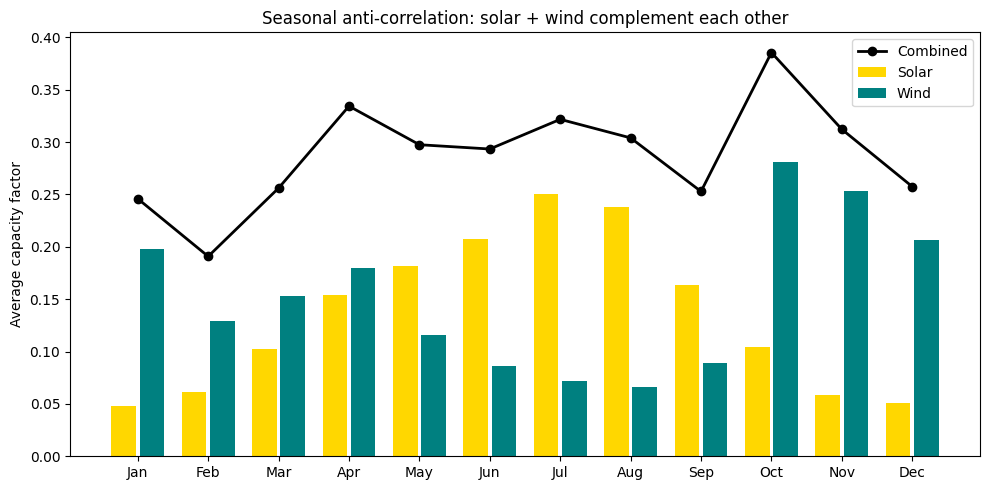

Coefficient of variation (monthly):
  Solar only:  0.52
  Wind only:   0.45
  Combined:    0.17  (lower = more stable)


In [7]:
rng = np.random.default_rng(42)
solar_p = solar.generate_profile(tg, rng)
rng2 = np.random.default_rng(43)
wind_p = wind.generate_profile(tg, rng2)

# Monthly averages
solar_monthly = [solar_p[tg.month == m].mean() for m in range(1, 13)]
wind_monthly = [wind_p[tg.month == m].mean() for m in range(1, 13)]
combined = [s + w for s, w in zip(solar_monthly, wind_monthly)]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(12)
ax.bar(x - 0.2, solar_monthly, 0.35, label='Solar', color='gold')
ax.bar(x + 0.2, wind_monthly, 0.35, label='Wind', color='teal')
ax.plot(x, combined, 'ko-', label='Combined', lw=2, ms=6)

ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_ylabel('Average capacity factor')
ax.set_title('Seasonal anti-correlation: solar + wind complement each other')
ax.legend()

plt.tight_layout()
plt.show()

cv_solar = np.std(solar_monthly) / np.mean(solar_monthly)
cv_wind = np.std(wind_monthly) / np.mean(wind_monthly)
cv_combined = np.std(combined) / np.mean(combined)
print(f"Coefficient of variation (monthly):")
print(f"  Solar only:  {cv_solar:.2f}")
print(f"  Wind only:   {cv_wind:.2f}")
print(f"  Combined:    {cv_combined:.2f}  (lower = more stable)")

## 4. Play with parameters

Modify the wind parameters to see their effect on the availability profile:

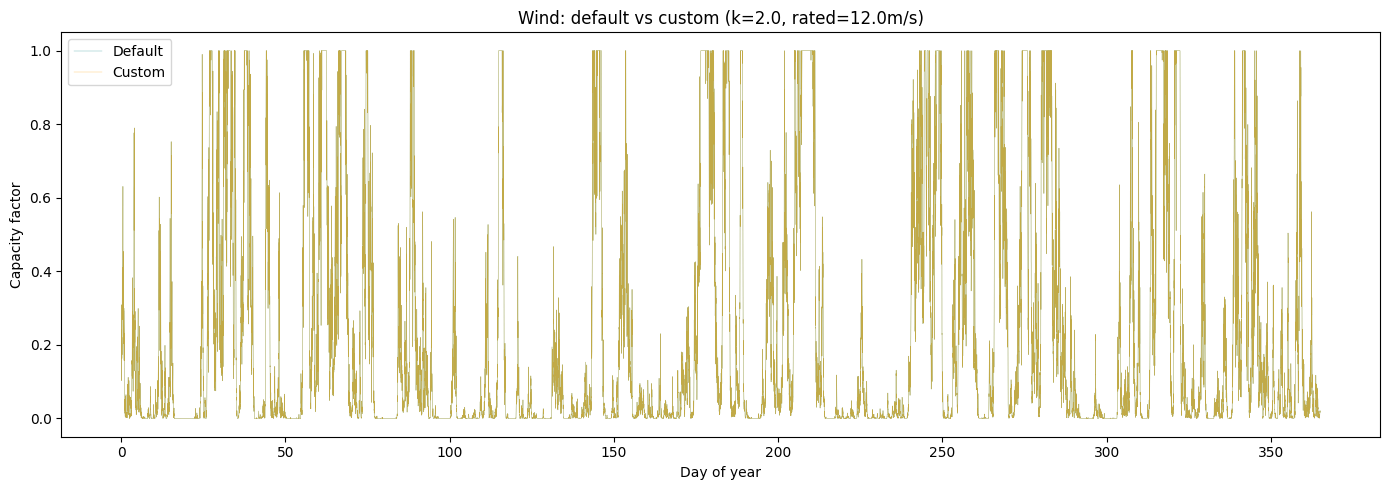

Average CF — default: 0.227, custom: 0.227


In [8]:
# ── PLAY WITH THESE ──────────────────────────────────────
custom_weibull_k = 2.0      # try 1.5 (more variable) to 3.0 (more regular)
custom_cut_in = 3.0         # try 2-5 m/s
custom_rated = 12.0         # try 10-15 m/s
custom_cut_out = 25.0       # try 20-30 m/s
# ─────────────────────────────────────────────────────────

wind_custom = WindAvailability(
    weibull_k=custom_weibull_k,
    cut_in=custom_cut_in,
    rated=custom_rated,
    cut_out=custom_cut_out,
)

profile_default = wind.generate_profile(tg, np.random.default_rng(42))
profile_custom = wind_custom.generate_profile(tg, np.random.default_rng(42))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(days_axis, profile_default, lw=0.3, alpha=0.6, label='Default', color='teal')
ax.plot(days_axis, profile_custom, lw=0.3, alpha=0.6, label='Custom', color='orange')
ax.set_xlabel('Day of year')
ax.set_ylabel('Capacity factor')
ax.set_title(f'Wind: default vs custom (k={custom_weibull_k}, rated={custom_rated}m/s)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average CF — default: {profile_default.mean():.3f}, custom: {profile_custom.mean():.3f}")

## Key Takeaways

1. **Solar** is predictable in *shape* (Gaussian daily bell) but variable in *magnitude* (cloud Markov chain). Cloudy days cut output to 15–40% of clear sky.
2. **Wind** is highly **autocorrelated** — the AR(1) with $\phi=0.995$ means wind events persist for hours to days, creating clustering. This is critical for storage sizing.
3. The **power curve** nonlinearity means small changes in wind speed near cut-in or rated speed have large effects on output. Above rated, output is flat.
4. **Anti-correlation**: wind peaks in winter (lambda ~8.5 m/s), solar peaks in summer (factor 1.0). Combined, they produce a more stable renewable output.
5. Neither model captures **spatial correlation** — all wind farms see the same process. This is conservative (overestimates variability in a diversified fleet).

**Next notebook**: [04 — Generators & Merit Order](./04_generators_and_merit_order.ipynb) — how generators are assembled and the merit order works.